In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_json("../results/yar.json")

print(data["device_count"].value_counts())

data

device_count
1    1000
2    1000
4    1000
Name: count, dtype: int64


,timestamp,time,device_count,max_seq_len,prompt_length,max_tokens,yield_probability,total_generated_tokens,yield_count
0,2025-10-07 14:15:39.852236271,8.179855,1,8192,107,658,0.200051,658,10530
1,2025-10-07 14:15:44.974962711,4.937339,1,8192,107,395,0.734647,395,6322
2,2025-10-07 14:15:49.065584183,3.943001,1,8192,107,313,0.592685,313,5010
3,2025-10-07 14:15:55.764583588,6.457386,1,8192,107,518,0.387458,518,8290
4,2025-10-07 14:15:57.519964457,1.692186,1,8192,107,132,0.384918,132,2114
...,...,...,...,...,...,...,...,...,...
2995,2025-10-08 02:51:03.671911240,9.634983,4,8192,107,775,0.899660,775,49608
2996,2025-10-08 02:51:24.845960379,5.095808,4,8192,107,406,0.594109,406,25992
2997,2025-10-08 02:51:50.804676771,6.223010,4,8192,107,498,0.465803,498,31880
2998,2025-10-08 02:52:09.606092691,4.525158,4,8192,107,360,0.999489,360,23048


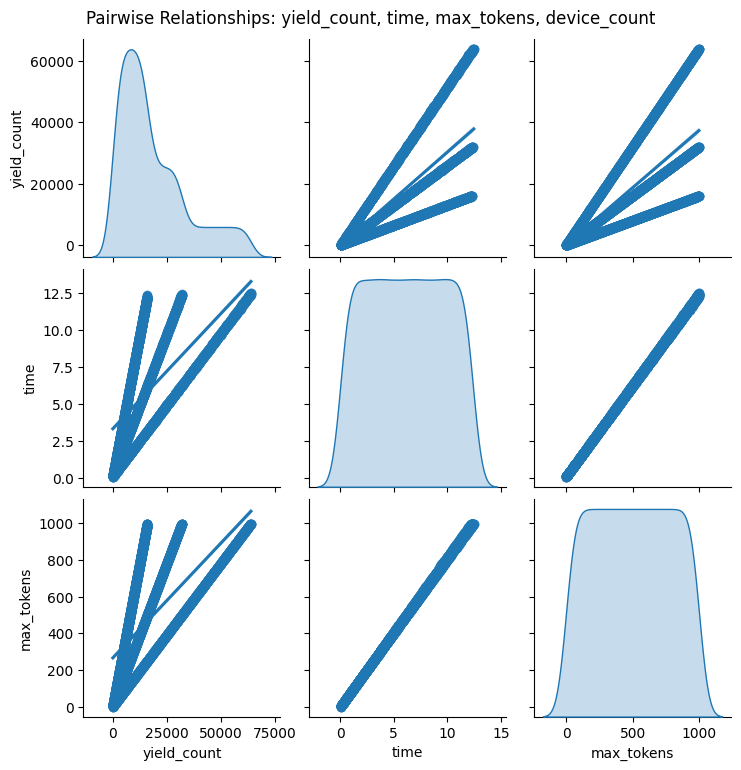

Correlation matrix:
              yield_count      time  max_tokens
yield_count     1.000000  0.690389    0.683333
time            0.690389  1.000000    0.999930
max_tokens      0.683333  0.999930    1.000000


In [3]:
import seaborn as sns

# Select relevant columns
corr_data = data[["yield_count", "time", "max_tokens", ]]# "device_count"]]

# Pairplot to visualize relationships
sns.pairplot(corr_data, kind="reg", diag_kind="kde")
plt.suptitle("Pairwise Relationships: yield_count, time, max_tokens, device_count", y=1.02)
plt.show()

# Display correlation matrix
corr_matrix = corr_data.corr()
print("Correlation matrix:\n", corr_matrix)

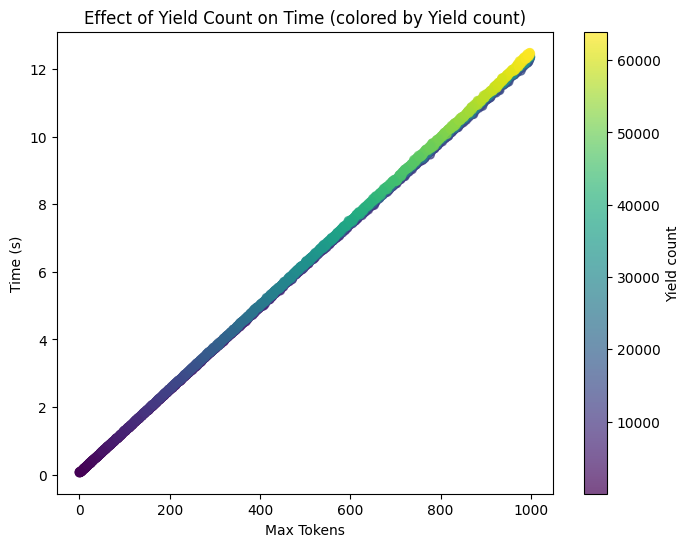

In [4]:
# Scatter plot: yield_count vs time, colored by max_tokens
plt.figure(figsize=(8, 6))
sc = plt.scatter(data["max_tokens"], data["time"], c=data["yield_count"], cmap="viridis", alpha=0.7)
plt.xlabel("Max Tokens")
plt.ylabel("Time (s)")
plt.title("Effect of Yield Count on Time (colored by Yield count)")
cbar = plt.colorbar(sc)
cbar.set_label("Yield count")
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

scaler = MinMaxScaler()
df = data.copy()
df["max_tokens_sq"] = df["max_tokens"]**2
X_raw = df[["max_tokens", "max_tokens_sq", "yield_count", "device_count", "time"]]
X_norm = scaler.fit_transform(X_raw)

X1 = pd.DataFrame(X_norm, columns=X_raw.columns)[["max_tokens"]]
X2 = pd.DataFrame(X_norm, columns=X_raw.columns)[["max_tokens", "max_tokens_sq"]]
X3 = pd.DataFrame(X_norm, columns=X_raw.columns)[["max_tokens", "max_tokens_sq", "yield_count"]]
X4 = pd.DataFrame(X_norm, columns=X_raw.columns)[["max_tokens", "max_tokens_sq", "yield_count", "device_count"]]
y = X_raw["time"]

X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)
X3 = sm.add_constant(X3)
X4 = sm.add_constant(X4)

model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()
model4 = sm.OLS(y, X4).fit()

print(model4.summary())
print("F-test p-value for adding device_count:", model4.compare_f_test(model3)[1])
print("F-test p-value for adding yield_count:", model3.compare_f_test(model2)[1])
print("F-test p-value for adding max_tokens_sq:", model2.compare_f_test(model1)[1])

print("R-squared values:")
print("Model 1 (max_tokens):", model1.rsquared)
print("Model 2 (max_tokens + max_tokens_sq):", model2.rsquared)
print("Model 3 (max_tokens + max_tokens_sq + yield_count):", model3.rsquared)
print("Model 4 (max_tokens + max_tokens_sq + yield_count + device_count):", model4.rsquared)


                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.687e+07
Date:                Tue, 07 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:10:20   Log-Likelihood:                 6968.6
No. Observations:                3000   AIC:                        -1.393e+04
Df Residuals:                    2995   BIC:                        -1.390e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0540      0.002     33.843

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.687e+07
Date:                Tue, 07 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:10:20   Log-Likelihood:                 6968.6
No. Observations:                3000   AIC:                        -1.393e+04
Df Residuals:                    2995   BIC:                        -1.390e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0540      0.002     33.843

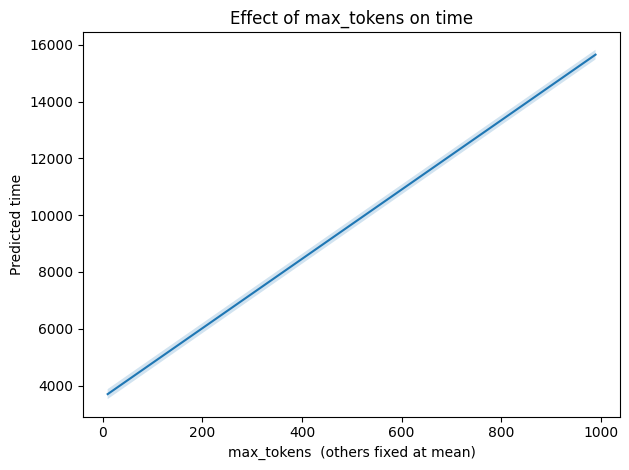

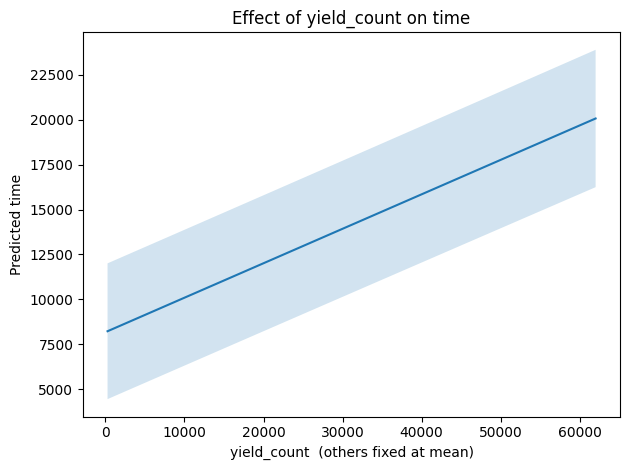

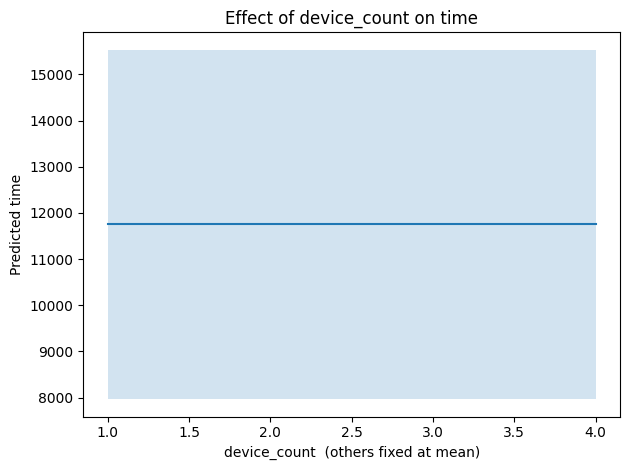

In [6]:
# pip install pandas numpy statsmodels matplotlib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assume df already has: time, max_tokens, yield_count
df = data.copy()

# ------------------------------------------------------------
# 1) Add quadratic terms
# ------------------------------------------------------------
df["max_tokens_sq"] = df["max_tokens"]**2

# ------------------------------------------------------------
# 2) Fit quadratic OLS model
# ------------------------------------------------------------
scaler = MinMaxScaler()
X_raw = df[["max_tokens", "yield_count", "max_tokens_sq", "device_count"]]
X_norm = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_norm, columns=X_raw.columns)
X = sm.add_constant(X)
y = df["time"]

quad_model = sm.OLS(y, X).fit()
print(quad_model.summary())

# ------------------------------------------------------------
# 3) Effect plot for max_tokens (quadratic)
# ------------------------------------------------------------
def quadratic_effect_plot(var_name, hold_vars, n=200):
    hold_vals = {k: df[k].mean() for k in hold_vars + ["max_tokens_sq"]}
    vmin, vmax = np.percentile(df[var_name], [1, 99])
    grid = np.linspace(vmin, vmax, n)

    design = pd.DataFrame({
        "const": 1.0,
        "max_tokens": grid if var_name == "max_tokens" else hold_vals["max_tokens"],
        "yield_count": grid if var_name == "yield_count" else hold_vals["yield_count"],
        "max_tokens_sq": (grid if var_name == "max_tokens" else hold_vals["max_tokens_sq"]),
        "device_count": grid if var_name == "device_count" else hold_vals["device_count"],
    })

    pred_res = quad_model.get_prediction(design).summary_frame(alpha=0.05)

    plt.figure()
    plt.plot(grid, pred_res["mean"])
    plt.fill_between(grid, pred_res["mean_ci_lower"], pred_res["mean_ci_upper"], alpha=0.2)
    plt.xlabel(var_name + f"  (others fixed at mean)")
    plt.ylabel("Predicted time")
    plt.title(f"Effect of {var_name} on time")
    plt.tight_layout()
    plt.show()

quadratic_effect_plot("max_tokens", ["yield_count", "device_count"])
quadratic_effect_plot("yield_count", ["max_tokens", "device_count"])
quadratic_effect_plot("device_count", ["max_tokens", "yield_count"])


In [7]:
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression

# Fit a linear regression model for sensitivity analysis
lr = LinearRegression()
lr.fit(X_raw, y)

# Permutation importance (global sensitivity)
result = permutation_importance(lr, X_raw, y, n_repeats=10, random_state=42, scoring='neg_mean_squared_error')

# Display results
importances = pd.Series(result.importances_mean, index=X_raw.columns)
importances = importances.sort_values(ascending=False)
print("Permutation Importance (Global Sensitivity):")
print(importances)

Permutation Importance (Global Sensitivity):
max_tokens       2.491476e+01
yield_count      4.516384e-03
max_tokens_sq    6.711117e-06
device_count     5.191766e-08
dtype: float64


In [8]:
data = pd.read_json("../results/yars.json")
data

,timestamp,time,device_count,max_seq_len,prompt_length,max_tokens,yield_probability,total_generated_tokens,yield_count
0,2025-10-06 17:17:07.066041946,0.243878,1,8192,107,16,0.0,16,258
1,2025-10-06 17:17:07.305377483,0.231319,1,8192,107,16,0.2,16,258
2,2025-10-06 17:17:07.540072918,0.225620,1,8192,107,16,0.4,16,258
3,2025-10-06 17:17:07.780017614,0.231794,1,8192,107,16,0.6,16,258
4,2025-10-06 17:17:08.037247896,0.249183,1,8192,107,16,0.8,16,258
...,...,...,...,...,...,...,...,...,...
6475,2025-10-06 23:30:13.705555201,3.231511,4,8192,107,256,0.2,256,16392
6476,2025-10-06 23:30:27.108988762,3.227584,4,8192,107,256,0.4,256,16392
6477,2025-10-06 23:30:40.501376151,3.218070,4,8192,107,256,0.6,256,16392
6478,2025-10-06 23:30:53.818138599,3.196238,4,8192,107,256,0.8,256,16392


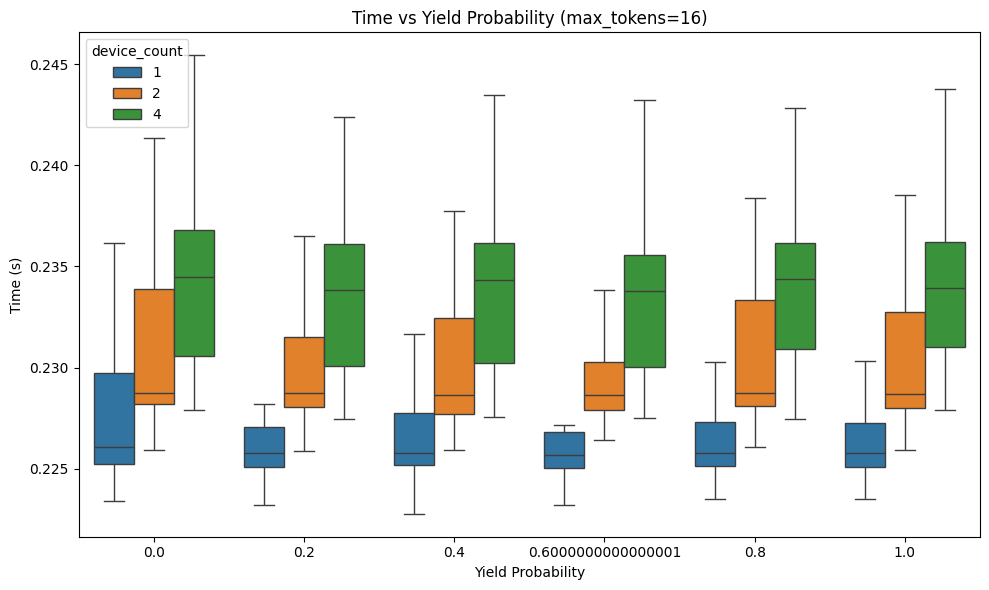

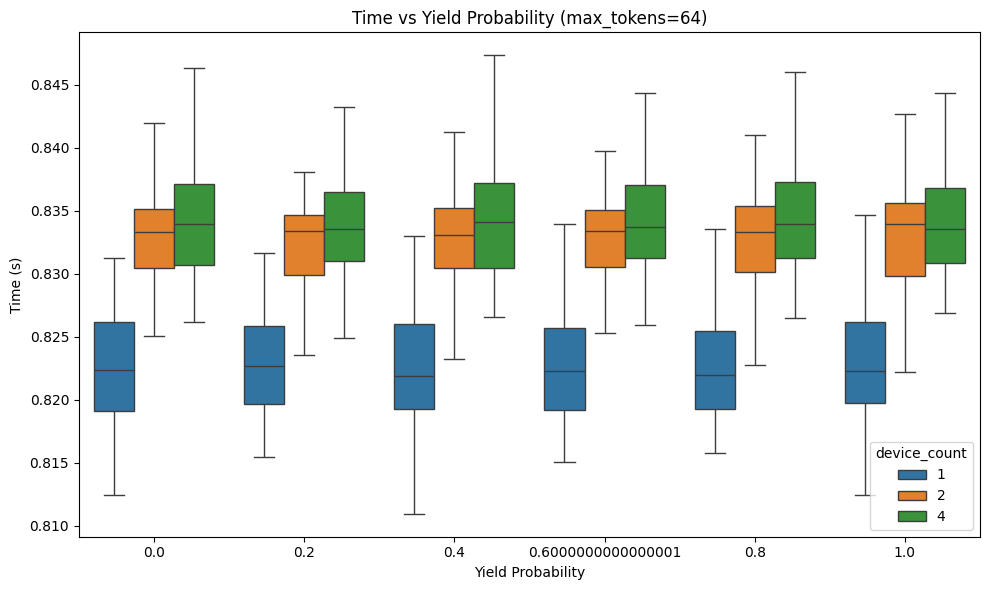

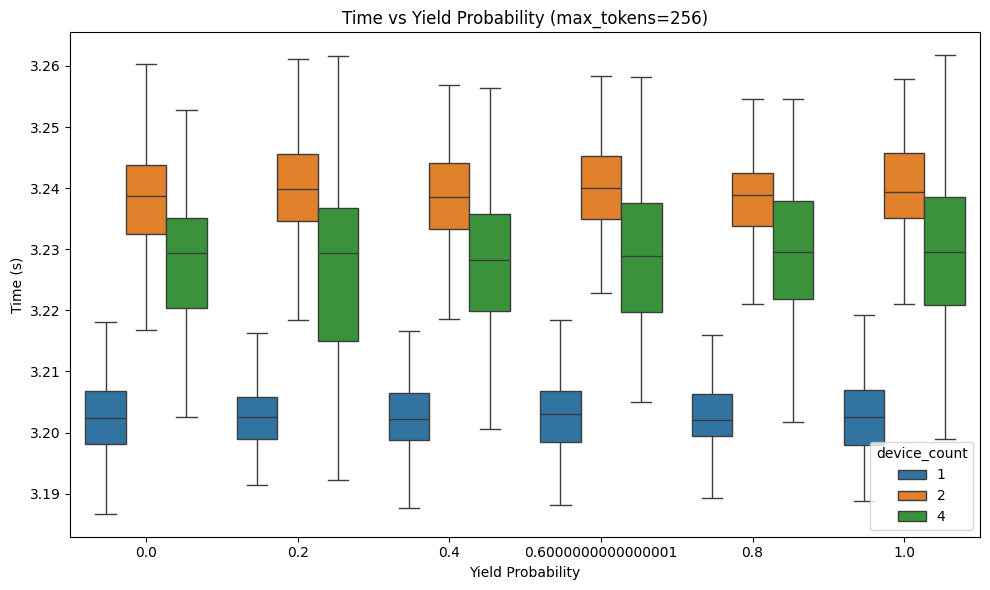

In [9]:
import seaborn as sns

for mt in sorted(data["max_tokens"].unique()):
    plt.figure(figsize=(10, 6))
    subset = data[data["max_tokens"] == mt]
    sns.boxplot(
        data=subset,
        x="yield_probability",
        y="time",
        hue="device_count",
        palette="tab10",
        showfliers=False
    )
    plt.title(f"Time vs Yield Probability (max_tokens={mt})")
    plt.xlabel("Yield Probability")
    plt.ylabel("Time (s)")
    plt.legend(title="device_count")
    plt.tight_layout()
    plt.show()


In [10]:
data[(data["device_count"]==1) & (data["max_tokens"]==4) & (data["yield_probability"]==0.0)]["time"].mean()

nan

In [11]:
from scipy.stats import ks_2samp

# Group by yield_count
low_yield = data["yield_count"].quantile(0.25)
high_yield = data["yield_count"].quantile(0.75)

group_low = data[data["yield_count"] <= low_yield]["time"]
group_high = data[data["yield_count"] >= high_yield]["time"]

ks_stat, ks_pvalue = ks_2samp(group_low, group_high)
print(f"KS statistic: {ks_stat:.4f}, p-value: {ks_pvalue:.4g}")


KS statistic: 0.9569, p-value: 0
